In [1]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [2]:

model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:

img_path = '/content/dog.png'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)


In [8]:

preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=5)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n02106662', 'German_shepherd', np.float32(0.8983364)), ('n02105162', 'malinois', np.float32(0.06668014)), ('n02105412', 'kelpie', np.float32(0.008720827)), ('n03803284', 'muzzle', np.float32(0.0050805984)), ('n02107142', 'Doberman', np.float32(0.0021401849))]


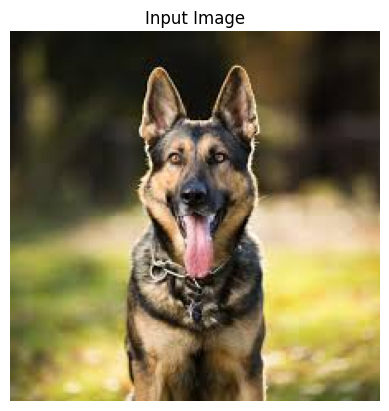

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top Predictions:
1. German_shepherd - 89.83%
2. malinois - 6.67%
3. kelpie - 0.87%


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions


# Load pretrained ResNet50 model
model = ResNet50(weights="imagenet")


def predict_image(img_path, top_k=3):
    """
    Predict the class of an image using pretrained ResNet50.
    """

    if not os.path.exists(img_path):
        print("Image not found:", img_path)
        return

    # Load image
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension: (224,224,3) -> (1,224,224,3)
    x = np.expand_dims(x, axis=0)

    # Preprocess for ResNet50
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=top_k)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


# Example usage
img_path = "/content/dog.png"
predict_image(img_path, top_k=3)

Saving dragen.png to dragen (1).png
Uploaded file: dragen (1).png


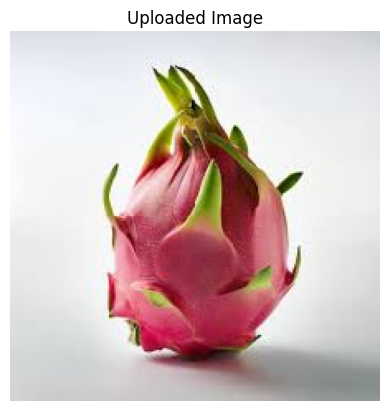

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Top Predictions:
1. vase - 65.40%
2. artichoke - 10.58%
3. strawberry - 6.63%
4. soap_dispenser - 1.93%
5. ice_cream - 1.77%
6. pineapple - 1.66%
7. candle - 0.76%
8. pot - 0.72%
9. bakery - 0.69%
10. perfume - 0.68%


In [4]:
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

model = ResNet50(weights="imagenet")

def predict_image(img_path, top_k=3):
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    results = decode_predictions(preds, top=top_k)[0]

    print("Top Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)
    predict_image(filename, top_k=10)

Saving dragen.png to dragen (2).png


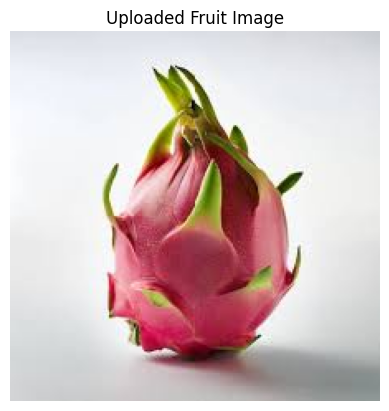

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Top Predictions:
1. vase --> 65.40%
2. artichoke --> 10.58%
3. strawberry --> 6.63%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = ResNet50(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    # Load image
    img = keras.utils.load_img(filename, target_size=(224,224))

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Fruit Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension
    x = np.expand_dims(x, axis=0)

    # Preprocess image
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=3)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")